## L2_wind_product and TCVA and SARGEO (16 janvier)

In [2]:
cyclobs_path = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v00r00/cyclobs"
canal = "IRWIN"
import os
compt = 0
years = []
bassins = []
for cyc_id in os.listdir(cyclobs_path):
    irwin_path = os.path.join(cyclobs_path,cyc_id,canal)

    compt+= len(os.listdir(irwin_path))
    for nc in os.listdir(irwin_path):
        years.append(cyc_id[-4:])
        bassins.append(cyc_id[:2])
compt

1970

In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv("https://cyclobs.ifremer.fr/app/api/getData?include_cols=cyclone_name,data_url,analysis_vmax,analysis_rmax,vmax,analysis_center_quality_flag,cyclone_name,cyclone_start_date,cyclone_stop_date,acquisition_start_time")
l2_df = df.copy()
for i,row in l2_df.iterrows():
    l2_df.loc[i,"match_with_sargeo"] = os.path.basename(row["data_url"])[:-15]
for i,row in df[~df["analysis_center_quality_flag"].isnull()].iterrows():
    df.loc[i,"match_with_sargeo"] = os.path.basename(row["data_url"])[:-15]
tcva_df = df[~df["match_with_sargeo"].isnull()].copy()
print(
df["match_with_sargeo"].iloc[0])
len(l2_df),len(tcva_df)


rcm1-sc100ma-owi-cm-20220926t112558-20220926t112806-00003


(2719, 2241)

In [4]:
df[~df["analysis_center_quality_flag"].isnull()].isnull().sum()

data_url                         0
acquisition_start_time           0
cyclone_name                     0
cyclone_start_date               0
cyclone_stop_date                0
vmax (m/s)                       0
analysis_vmax                   75
analysis_rmax                   75
analysis_center_quality_flag     0
match_with_sargeo                0
dtype: int64

In [5]:
years_l2 = []
years_tcva = []
for i,row in l2_df.iterrows():
    years_l2.append(row["cyclone_start_date"].split("-")[0])
for i,row in tcva_df.iterrows():
    years_tcva.append(row["cyclone_start_date"].split("-")[0])

np.unique(years_l2,return_counts=True)

(array(['2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
        '2021', '2022', '2023', '2024', '2025', '2026'], dtype='<U4'),
 array([  3,  19,  30,  63,  63, 184, 146, 128, 157, 122, 521, 533, 722,
         28]))

In [6]:
df = l2_df.copy()

In [7]:
import os
import re
import pandas as pd
from datetime import datetime, timedelta


TIME_FMT = "%Y%m%dT%H%M%S"

def parse_product_id(name: str):
    """
    Ex: rcm1-sc100ma-owi-cm-20220926t112558-20220926t112806-00003
    Returns: (sat, start_dt, end_dt) or (None,None,None)
    """
    name = name.lower()
    m = re.search(r"^(?P<sat>[^-]+).*-(?P<t0>\d{8}t\d{6})-(?P<t1>\d{8}t\d{6})-", name)
    if not m:
        return None, None, None
    sat = m.group("sat")
    t0 = datetime.strptime(m.group("t0").upper(), TIME_FMT)
    t1 = datetime.strptime(m.group("t1").upper(), TIME_FMT)
    return sat, t0, t1

def build_match_key_from_url(url: str):
    return os.path.basename(url)[:-15].lower()

def build_match_key_from_filename(nc_filename: str):
    return nc_filename[:-25].lower()

# df = pd.read_csv("https://cyclobs.ifremer.fr/app/api/getData?include_cols=data_url")
# df["match_with_sargeo"] = df["data_url"].apply(build_match_key_from_url)


parsed = df["match_with_sargeo"].apply(parse_product_id)
df["sat"] = parsed.apply(lambda x: x[0])
df["t0"]  = parsed.apply(lambda x: x[1])
df["t1"]  = parsed.apply(lambda x: x[2])


df_match_series = df["match_with_sargeo"].astype(str)
df_by_sat = {sat: sub.reset_index(drop=False) for sat, sub in df.dropna(subset=["sat","t0"]).groupby("sat")}

tol = timedelta(minutes=3)
count_exact = 0
count_fuzzy = 0
count_none  = 0
matches = []

for cyc_id in os.listdir(cyclobs_path):
    irwin_path = os.path.join(cyclobs_path, cyc_id, canal)
    if not os.path.isdir(irwin_path):
        continue

    for nc in os.listdir(irwin_path):
        match = build_match_key_from_filename(nc)
        match_df = df[df_match_series.str.contains(match, na=False)]
        if len(match_df) == 1:
            count_exact += 1
            matches.append({
                "cyclone_name":match_df["cyclone_name"].iloc[0],
                "cyclone_id": cyc_id,
                "file": nc,
                "match_type": "exact_contains",
                "df_index": int(match_df.index[0]),
                "df_match_with_sargeo": match_df["match_with_sargeo"].iloc[0],
            })
            continue
        sat, t0, t1 = parse_product_id(match)
        if sat is None or t0 is None:
            count_none += 1
            matches.append({
                "cyclone_id": cyc_id,
                "file": nc,
                "match_type": "no_parse",
                "df_index": None,
                "df_match_with_sargeo": None,
            })
            continue

        sub = df_by_sat.get(sat)
        if sub is None or len(sub) == 0:
            count_none += 1
            matches.append({
                "cyclone_id": cyc_id,
                "file": nc,
                "match_type": "no_sat_in_df",
                "df_index": None,
                "df_match_with_sargeo": None,
            })
            continue

        dt = (sub["t0"] - t0).abs()
        cand = sub[dt <= tol].copy()
        
        if len(cand) == 1:
            count_fuzzy += 1
            row = cand.iloc[0]
            matches.append({
                "cyclone_name":row["cyclone_name"],
                "cyclone_id": cyc_id,
                "file": nc,
                "match_type": "fuzzy_sat_time",
                "df_index": int(row["index"]),  # original df index
                "df_match_with_sargeo": row["match_with_sargeo"],
                "time_diff_s": float(abs((row["t0"] - t0).total_seconds())),
            })
        elif len(cand) > 1:
            # pick the closest in time
            cand["dt_s"] = (cand["t0"] - t0).abs().dt.total_seconds()
            row = cand.sort_values("dt_s").iloc[0]
            count_fuzzy += 1
            matches.append({
                "cyclone_name":row["cyclone_name"],
                "cyclone_id": cyc_id,
                "file": nc,
                "match_type": "fuzzy_sat_time_closest",
                "df_index": int(row["index"]),
                "df_match_with_sargeo": row["match_with_sargeo"],
                "time_diff_s": float(row["dt_s"]),
                "num_candidates": int(len(cand)),
            })
        else:
            count_none += 1
            matches.append({
                "cyclone_id": cyc_id,
                "file": nc,
                "match_type": "no_match",
                "df_index": None,
                "df_match_with_sargeo": None,
            })

print("Exact matches:", count_exact)
print("Fuzzy matches:", count_fuzzy)
print("total matched:", count_exact+count_fuzzy)
print("No match:", count_none)

matches_df = pd.DataFrame(matches)


Exact matches: 1829
Fuzzy matches: 136
total matched: 1965
No match: 5


In [8]:
years_matched_sargeo_l2 = []
bassin_matched_sargeo_l2 = []
for i,row in matches_df[~matches_df["df_index"].isnull()].iterrows():
    cyc_id = row["cyclone_id"]
    years_matched_sargeo_l2.append(cyc_id[-4:])
    bassin_matched_sargeo_l2.append(cyc_id[:2])
    

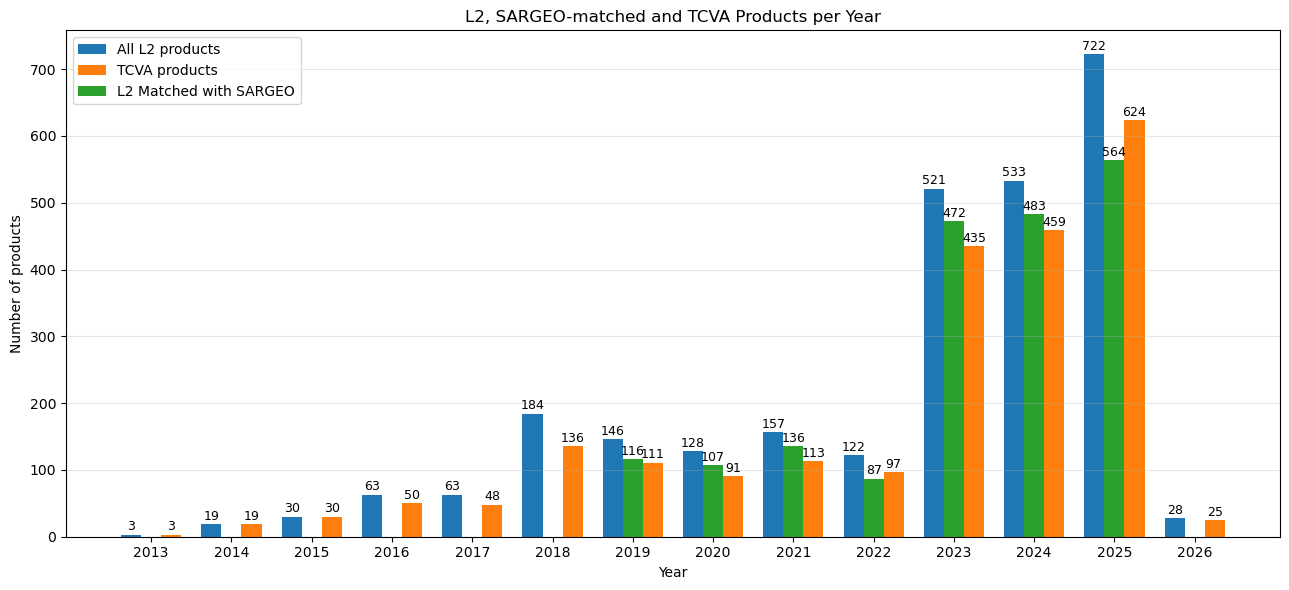

(np.int64(2719), np.int64(2241), np.int64(1965))

In [9]:
import numpy as np
import matplotlib.pyplot as plt

years_l2 = np.array(years_l2, dtype=int)
years_matched = np.array(years_matched_sargeo_l2, dtype=int)
tcva_years = np.array(years_tcva, dtype=int)

# Counts
all_years, l2_counts = np.unique(years_l2, return_counts=True)
_, matched_counts = np.unique(years_matched, return_counts=True)
_, tcva_counts = np.unique(tcva_years, return_counts=True)

# Align on all_years
matched_map = dict(zip(*np.unique(years_matched, return_counts=True)))
tcva_map = dict(zip(*np.unique(tcva_years, return_counts=True)))

matched_aligned = np.array([matched_map.get(y, 0) for y in all_years])
tcva_aligned = np.array([tcva_map.get(y, 0) for y in all_years])
fig, ax = plt.subplots(figsize=(13, 6))

width = 0.25
x = np.arange(len(all_years))

# Bars
bars_l2 = ax.bar(x - width, l2_counts, width, label="All L2 products")
bars_tcva = ax.bar(x + width, tcva_aligned, width, label="TCVA products")

bars_matched = ax.bar(x, matched_aligned, width, label="L2 Matched with SARGEO")

# Labels & title
ax.set_title("L2, SARGEO-matched and TCVA Products per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of products")
ax.set_xticks(x)
ax.set_xticklabels(all_years)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- Annotate values ---
for bars in [bars_l2, bars_matched, bars_tcva]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 2,
                f"{int(h)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.tight_layout()
plt.show()

(l2_counts.sum(),tcva_aligned.sum(),matched_aligned.sum())

In [10]:
df = tcva_df.copy()

In [11]:
import os
import re
import pandas as pd
from datetime import datetime, timedelta


TIME_FMT = "%Y%m%dT%H%M%S"

def parse_product_id(name: str):
    """
    Ex: rcm1-sc100ma-owi-cm-20220926t112558-20220926t112806-00003
    Returns: (sat, start_dt, end_dt) or (None,None,None)
    """
    name = name.lower()
    m = re.search(r"^(?P<sat>[^-]+).*-(?P<t0>\d{8}t\d{6})-(?P<t1>\d{8}t\d{6})-", name)
    if not m:
        return None, None, None
    sat = m.group("sat")
    t0 = datetime.strptime(m.group("t0").upper(), TIME_FMT)
    t1 = datetime.strptime(m.group("t1").upper(), TIME_FMT)
    return sat, t0, t1

def build_match_key_from_url(url: str):
    return os.path.basename(url)[:-15].lower()

def build_match_key_from_filename(nc_filename: str):
    return nc_filename[:-25].lower()

# df = pd.read_csv("https://cyclobs.ifremer.fr/app/api/getData?include_cols=data_url")
# df["match_with_sargeo"] = df["data_url"].apply(build_match_key_from_url)


parsed = df["match_with_sargeo"].apply(parse_product_id)
df["sat"] = parsed.apply(lambda x: x[0])
df["t0"]  = parsed.apply(lambda x: x[1])
df["t1"]  = parsed.apply(lambda x: x[2])


df_match_series = df["match_with_sargeo"].astype(str)
df_by_sat = {sat: sub.reset_index(drop=False) for sat, sub in df.dropna(subset=["sat","t0"]).groupby("sat")}

tol = timedelta(minutes=3)
count_exact = 0
count_fuzzy = 0
count_none  = 0
matches = []

for cyc_id in os.listdir(cyclobs_path):
    irwin_path = os.path.join(cyclobs_path, cyc_id, canal)
    if not os.path.isdir(irwin_path):
        continue

    for nc in os.listdir(irwin_path):
        match = build_match_key_from_filename(nc)
        match_df = df[df_match_series.str.contains(match, na=False)]
        
        if len(match_df) == 1:
            
            count_exact += 1
            matches.append({
                "cyclone_name":match_df["cyclone_name"].iloc[0],
                "cyclone_id": cyc_id,
                "acquisition_start_time":match_df["acquisition_start_time"].iloc[0],
                "file": nc,
                
                "match_type": "exact_contains",
                "df_index": int(match_df.index[0]),
                "df_match_with_sargeo": match_df["match_with_sargeo"].iloc[0],
                "analysis_center_quality_flag":match_df["analysis_center_quality_flag"].iloc[0],
                "analysis_vmax":match_df["analysis_vmax"].iloc[0],
                "analysis_rmax":match_df["analysis_rmax"].iloc[0],
                "vmax":match_df["vmax (m/s)"].iloc[0]       
                      })
            continue
        sat, t0, t1 = parse_product_id(match)
        if sat is None or t0 is None:
            count_none += 1
            matches.append({
                "cyclone_name":match_df["cyclone_name"],
                "cyclone_id": cyc_id,
                "acquisition_start_time":match_df["acquisition_start_time"].iloc[0],
                "file": nc,
                "match_type": "no_parse",
                "df_index": None,
                "df_match_with_sargeo": None,
                "analysis_center_quality_flag":match_df["analysis_center_quality_flag"],
                "analysis_vmax":match_df["analysis_vmax"],
                "analysis_rmax":match_df["analysis_rmax"],
                "vmax":match_df["vmax (m/s)"] 
            })
            continue

        sub = df_by_sat.get(sat)
        if sub is None or len(sub) == 0:
            count_none += 1
            matches.append({
                "cyclone_name":match_df["cyclone_name"],
                "cyclone_id": cyc_id,
                "acquisition_start_time":match_df["acquisition_start_time"].iloc[0],
                "file": nc,
                "match_type": "no_sat_in_df",
                "df_index": None,
                "df_match_with_sargeo": None,
                "analysis_center_quality_flag":match_df["analysis_center_quality_flag"],
                "analysis_vmax":match_df["analysis_vmax"],
                "analysis_rmax":match_df["analysis_rmax"],
                "vmax":match_df["vmax (m/s)"] 
            })
            continue

        dt = (sub["t0"] - t0).abs()
        cand = sub[dt <= tol].copy()
        
        if len(cand) == 1:
            count_fuzzy += 1
            row = cand.iloc[0]
            matches.append({
                "cyclone_name":row["cyclone_name"],
                "cyclone_id": cyc_id,
                "acquisition_start_time":row["acquisition_start_time"],
                "file": nc,
                "match_type": "fuzzy_sat_time",
                "df_index": int(row["index"]),  # original df index
                "df_match_with_sargeo": row["match_with_sargeo"],
                "time_diff_s": float(abs((row["t0"] - t0).total_seconds())),
                "analysis_center_quality_flag":row["analysis_center_quality_flag"],
                "analysis_vmax":row["analysis_vmax"],
                "analysis_rmax":row["analysis_rmax"],
                "vmax":row["vmax (m/s)"] 
            })
        elif len(cand) > 1:
            # pick the closest in time
            cand["dt_s"] = (cand["t0"] - t0).abs().dt.total_seconds()
            row = cand.sort_values("dt_s").iloc[0]
            count_fuzzy += 1
    
            
            matches.append({
                "cyclone_name":row["cyclone_name"],
                "cyclone_id": cyc_id,
                "acquisition_start_time":row["acquisition_start_time"],
                "file": nc,
                "match_type": "fuzzy_sat_time_closest",
                "df_index": int(row["index"]),
                "df_match_with_sargeo": row["match_with_sargeo"],
                "time_diff_s": float(row["dt_s"]),
                "num_candidates": int(len(cand)),
                "analysis_center_quality_flag":row["analysis_center_quality_flag"],
                "analysis_vmax":row["analysis_vmax"],
                "analysis_rmax":row["analysis_rmax"],
                "vmax":row["vmax (m/s)"] 
            })
        else:
            count_none += 1
            matches.append({
                "cyclone_name":match_df["cyclone_name"],
                "cyclone_id": cyc_id,
                "acquisition_start_time":row["acquisition_start_time"],
                "file": nc,
                "match_type": "no_match",
                "df_index": None,
                "df_match_with_sargeo": None,
                "analysis_center_quality_flag":match_df["analysis_center_quality_flag"],
                "analysis_vmax":match_df["analysis_vmax"],
                "analysis_rmax":match_df["analysis_rmax"],
                "vmax":match_df["vmax (m/s)"] 
            })

print("Exact matches:", count_exact)
print("Fuzzy matches:", count_fuzzy)
print("total matched:", count_exact+count_fuzzy)
print("No match:", count_none)

tcva_sargeo_df = pd.DataFrame(matches)


Exact matches: 1582
Fuzzy matches: 124
total matched: 1706
No match: 264


In [12]:
tcva_sargeo_df["match_type"].unique()

array(['exact_contains', 'fuzzy_sat_time', 'no_match'], dtype=object)

In [13]:
(tcva_sargeo_df["match_type"]!="no_match").sum()
tcva_in_sargeo_df = tcva_sargeo_df[tcva_sargeo_df["match_type"]!="no_match"]

In [14]:
years_matched_sargeo_tcva = []
bassin_matched_sargeo_tcva = []
for i,row in tcva_in_sargeo_df[~tcva_in_sargeo_df["df_index"].isnull()].iterrows():
    cyc_id = row["cyclone_id"]
    years_matched_sargeo_tcva.append(cyc_id[-4:])
    bassin_matched_sargeo_tcva.append(cyc_id[:2])
    

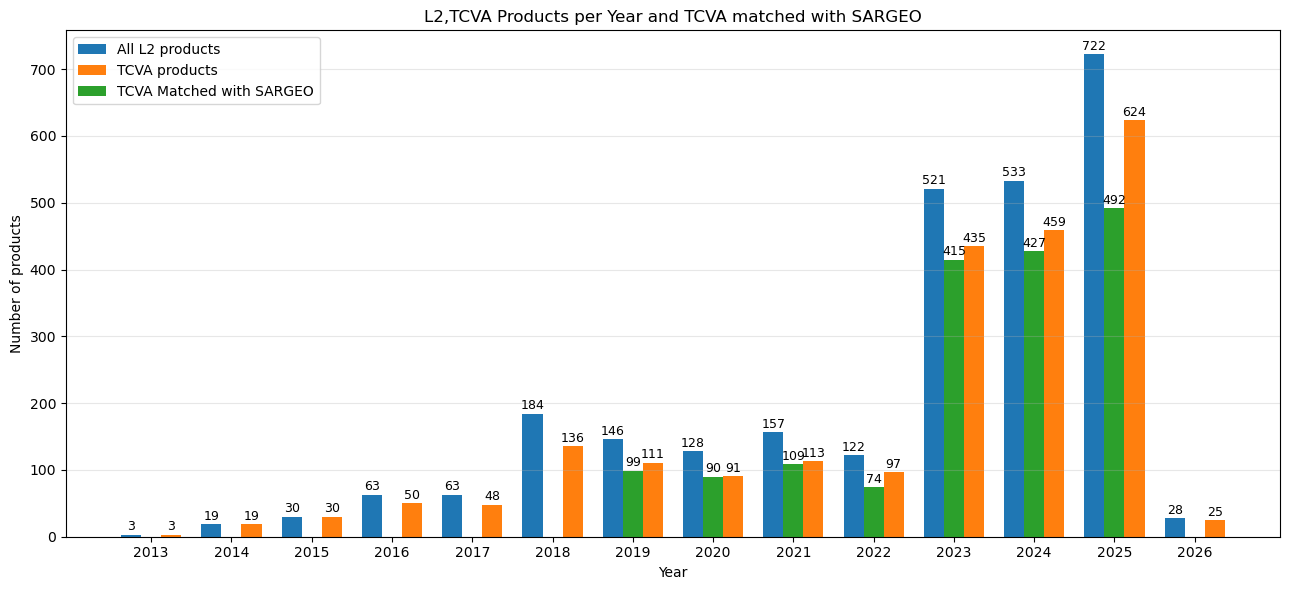

(np.int64(2719), np.int64(2241), np.int64(1706))

In [15]:
import numpy as np
import matplotlib.pyplot as plt

years_l2 = np.array(years_l2, dtype=int)
years_matched = np.array(years_matched_sargeo_tcva, dtype=int)
tcva_years = np.array(years_tcva, dtype=int)

# Counts
all_years, l2_counts = np.unique(years_l2, return_counts=True)
_, matched_counts = np.unique(years_matched, return_counts=True)
_, tcva_counts = np.unique(tcva_years, return_counts=True)

# Align on all_years
matched_map = dict(zip(*np.unique(years_matched, return_counts=True)))
tcva_map = dict(zip(*np.unique(tcva_years, return_counts=True)))

matched_aligned = np.array([matched_map.get(y, 0) for y in all_years])
tcva_aligned = np.array([tcva_map.get(y, 0) for y in all_years])
fig, ax = plt.subplots(figsize=(13, 6))

width = 0.25
x = np.arange(len(all_years))

# Bars
bars_l2 = ax.bar(x - width, l2_counts, width, label="All L2 products")
bars_tcva = ax.bar(x + width, tcva_aligned, width, label="TCVA products")

bars_matched = ax.bar(x, matched_aligned, width, label="TCVA Matched with SARGEO")

# Labels & title
ax.set_title("L2,TCVA Products per Year and TCVA matched with SARGEO")
ax.set_xlabel("Year")
ax.set_ylabel("Number of products")
ax.set_xticks(x)
ax.set_xticklabels(all_years)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# --- Annotate values ---
for bars in [bars_l2, bars_matched, bars_tcva]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                h + 2,
                f"{int(h)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

plt.tight_layout()
plt.show()

(l2_counts.sum(),tcva_aligned.sum(),matched_aligned.sum())

In [15]:
tcva_in_sargeo_df = tcva_sargeo_df[(tcva_sargeo_df["match_type"] =="fuzzy_sat_time") | (tcva_sargeo_df["match_type"] =="exact_contains")]
tcva_not_sargeo_df = tcva_sargeo_df[(tcva_sargeo_df["match_type"] !="fuzzy_sat_time") & (tcva_sargeo_df["match_type"] !="exact_contains")]
len(tcva_not_sargeo_df),len(tcva_in_sargeo_df)

(255, 1715)

In [16]:
import xarray as xr
import warnings
import numpy
def fxn():
    warnings.warn("deprecated", DeprecationWarning)
with warnings.catch_warnings(action="ignore"):
    fxn()
compt_storm_center = 0
bad_files = []

for i,row in tcva_in_sargeo_df.iterrows():
    cyc_id = row["cyclone_id"]
    irwin_path = os.path.join(cyclobs_path, cyc_id, canal)
    nc_path = os.path.join(irwin_path,row["file"])
    if not os.path.isdir(irwin_path):
        continue


    try:
        path = nc_path

        try:
            ds = xr.open_dataset(path, engine="netcdf4", decode_cf=False)
            if "storm_latitude" in ds.variables or "storm_latitude" in ds.data_vars:

                if isinstance(ds["storm_latitude"].values[4],numpy.float32):
                    compt_storm_center += 1

            ds.close()

        except Exception as e:
            bad_files.append((path, repr(e)))
            continue
    except Exception as e:
        continue

print("count storm center:", compt_storm_center)
print("bad files:", len(bad_files))

# save list of broken files
with open("bad_irwin_files.txt", "w") as f:
    for p, err in bad_files:
        f.write(f"{p}\t{err}\n")



count storm center: 1715
bad files: 0


In [17]:
## add sar files path to check center 
listing = pd.read_csv("/scale/user/mtannaou/alternance/excels/listing_sar_09_janvier.csv")
listing_3Km = listing[listing["Resolution"] == 3]
len(listing_3Km)

2694

In [18]:
for i,row in listing_3Km.iterrows():
    listing_3Km.loc[i,"matched_with_sargeo"] = os.path.basename(row["L2M path"])[:-9]
tcva_sargeo_df.columns

/tmp/ipykernel_3403911/1986172632.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  listing_3Km.loc[i,"matched_with_sargeo"] = os.path.basename(row["L2M path"])[:-9]


Index(['cyclone_name', 'cyclone_id', 'acquisition_start_time', 'file',
       'match_type', 'df_index', 'df_match_with_sargeo',
       'analysis_center_quality_flag', 'analysis_vmax', 'analysis_rmax',
       'vmax', 'time_diff_s'],
      dtype='object')

In [19]:
count_sar_path = 0
for i,row in tcva_sargeo_df.iterrows():
    match_path = listing_3Km[listing_3Km["matched_with_sargeo"] == row["df_match_with_sargeo"]]
    tcva_sargeo_df.loc[i,"sar_path"] = row["df_match_with_sargeo"]
    if len(match_path) == 1 :
        count_sar_path+=1

count_sar_path

1712

In [201]:
import xarray as xr
count_regridded_data = 0
file_not_exist = 0
sar_regrided_folder = "/scale/user/mtannaou/alternance/donnees_sar_aeqd_09_janvier"
for i,row in tcva_in_sargeo_df.iterrows():
    file = None
    cyc_id = row["cyclone_id"]
    cyc_id_path = os.path.join(sar_regrided_folder,cyc_id) if os.path.exists(os.path.join(sar_regrided_folder,cyc_id)) else os.path.join(sar_regrided_folder,cyc_id+"no_env")
    if not os.path.exists(cyc_id_path) :
        file_not_exist+=1
        continue                                              # pour year <2019

    for file_nc in os.listdir(cyc_id_path):
        if str(row["df_match_with_sargeo"]) in str(file_nc):
            file = file_nc
            file_path = os.path.join(cyc_id_path,file_nc)
            tcva_in_sargeo_df.loc[i,"sar_aeqd_path"] = file_path
            count_regridded_data +=1
            break
            
   
count_regridded_data,file_not_exist

/tmp/ipykernel_1947545/4188895236.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcva_in_sargeo_df.loc[i,"sar_aeqd_path"] = file_path


(1705, 0)

In [202]:
tcva_in_sargeo_df.isnull().sum()

cyclone_name                       0
cyclone_id                         0
acquisition_start_time             0
file                               0
match_type                         0
df_index                           0
df_match_with_sargeo               0
analysis_center_quality_flag       0
analysis_vmax                    105
analysis_rmax                    105
vmax                               0
time_diff_s                     1588
sar_aeqd_path                      9
dtype: int64

In [203]:
import os, numpy as np, xarray as xr

MIN_BYTES = 200_000
count_good = 0
nan_ratio_values = []
bad = []

for i, row in tcva_in_sargeo_df.iterrows():
    nan_ratio = None
    p = row["sar_aeqd_path"]
    if p is None or (isinstance(p, float) and np.isnan(p)) or not os.path.exists(p):
        bad.append((i, "missing", p))
        continue
    if os.path.getsize(p) < MIN_BYTES:
        bad.append((i, "too_small", p))
        continue

    try:
        with xr.open_dataset(p, engine="netcdf4", decode_cf=False) as ds:
            if "owiWindSpeed" not in ds:
                bad.append((i, "no_owiWindSpeed", p))
                continue

            owi = ds["owiWindSpeed"].values
            H, W = owi.shape
            y, x = np.ogrid[:H, :W]
            mask = (x - W//2)**2 + (y - H//2)**2 <= 50**2

            total = int(mask.sum())
            nan_sum = int(np.isnan(owi[mask]).sum())

            nan_ratio_values.append(nan_sum / total)
            count_good += 1
    
    except Exception as e:
        bad.append((i, f"open_failed:{type(e).__name__}", p))
    tcva_in_sargeo_df.loc[i,"nan_ratio_within_100km"] = nan_sum / total


print("good images:", count_good)
print("bad rows:", len(bad))
print("bad examples:", bad[:5])

/tmp/ipykernel_1947545/2624173823.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcva_in_sargeo_df.loc[i,"nan_ratio_within_100km"] = nan_sum / total


good images: 1704
bad rows: 10
bad examples: [(0, 'too_small', '/scale/user/mtannaou/alternance/donnees_sar_aeqd_09_janvier/sh142025/rcm1-sclnd-owi-cm-20250217t134001-20250217t134117-00003_aeqd.nc'), (374, 'missing', nan), (380, 'missing', nan), (1030, 'missing', nan), (1065, 'missing', nan)]


In [204]:
tcva_in_sargeo_df.isnull().sum()

cyclone_name                       0
cyclone_id                         0
acquisition_start_time             0
file                               0
match_type                         0
df_index                           0
df_match_with_sargeo               0
analysis_center_quality_flag       0
analysis_vmax                    105
analysis_rmax                    105
vmax                               0
time_diff_s                     1588
sar_aeqd_path                      9
nan_ratio_within_100km            10
dtype: int64

In [205]:
tcva_in_sargeo_df = tcva_in_sargeo_df[["cyclone_name","cyclone_id","acquisition_start_time","file","match_type","analysis_center_quality_flag","analysis_vmax","analysis_rmax","vmax","sar_aeqd_path","nan_ratio_within_100km"]]
tcva_in_sargeo_df[["cyclone_name","cyclone_id","acquisition_start_time","file","match_type","analysis_center_quality_flag","analysis_vmax","analysis_rmax","vmax","sar_aeqd_path","nan_ratio_within_100km"]].to_csv("TCVA_matched_with_SARGEO_df.csv")

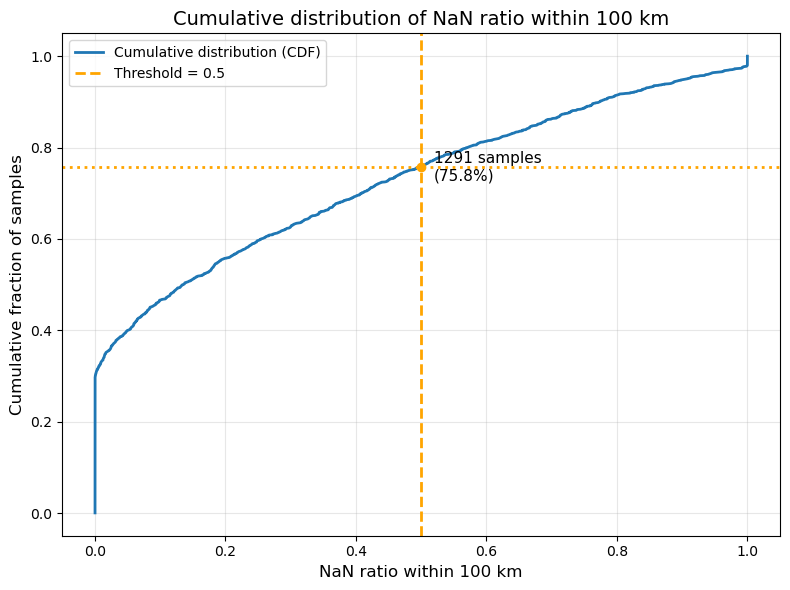

In [206]:
import numpy as np
import matplotlib.pyplot as plt

values = tcva_in_sargeo_df["nan_ratio_within_100km"].dropna().values
values = np.sort(values)

# CDF
cdf = np.arange(1, len(values) + 1) / len(values)

threshold = 0.5
count_below = np.sum(values <= threshold)
percent_below = 100 * count_below / len(values)

plt.figure(figsize=(8, 6))

plt.plot(values, cdf, linewidth=2, label="Cumulative distribution (CDF)")

# Threshold lines
plt.axvline(threshold, color="orange", linestyle="--", linewidth=2,
            label=f"Threshold = {threshold}")
plt.axhline(count_below / len(values), color="orange", linestyle=":", linewidth=2)

# Annotation
plt.scatter([threshold], [count_below / len(values)], color="orange", zorder=5)
plt.text(
    threshold + 0.02,
    count_below / len(values),
    f"{count_below} samples\n({percent_below:.1f}%)",
    va="center",
    fontsize=11
)

plt.xlabel("NaN ratio within 100 km", fontsize=12)
plt.ylabel("Cumulative fraction of samples", fontsize=12)
plt.title("Cumulative distribution of NaN ratio within 100 km", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [207]:
tcva_in_sargeo_df[tcva_in_sargeo_df["nan_ratio_within_100km"] < 0.5].isnull().sum()

cyclone_name                     0
cyclone_id                       0
acquisition_start_time           0
file                             0
match_type                       0
analysis_center_quality_flag     0
analysis_vmax                   32
analysis_rmax                   32
vmax                             0
sar_aeqd_path                    0
nan_ratio_within_100km           0
dtype: int64

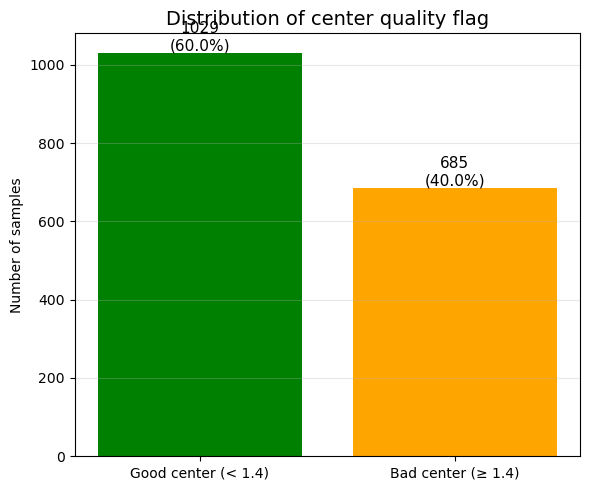

In [208]:
threshold = 1.4

good_center = tcva_in_sargeo_df[
    tcva_in_sargeo_df["analysis_center_quality_flag"] <= threshold
]

bad_center = tcva_in_sargeo_df[
    tcva_in_sargeo_df["analysis_center_quality_flag"] > threshold
]

n_good = len(good_center)
n_bad = len(bad_center)
n_total = n_good + n_bad

plt.figure(figsize=(6,5))

bars = plt.bar(
    ["Good center (< 1.4)", "Bad center (≥ 1.4)"],
    [n_good, n_bad],
    color=["green", "orange"]
)

# Ajouter les valeurs sur les barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}\n({100*height/n_total:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.ylabel("Number of samples")
plt.title("Distribution of center quality flag", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


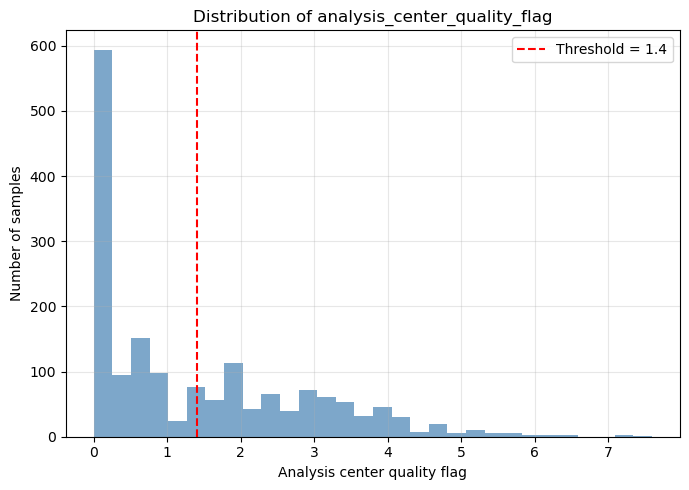

In [209]:
plt.figure(figsize=(7,5))
plt.hist(
    tcva_in_sargeo_df["analysis_center_quality_flag"],
    bins=30,
    color="steelblue",
    alpha=0.7
)

plt.axvline(1.4, color="red", linestyle="--", label="Threshold = 1.4")
plt.xlabel("Analysis center quality flag")
plt.ylabel("Number of samples")
plt.title("Distribution of analysis_center_quality_flag")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [210]:
analysis_vmax = tcva_in_sargeo_df[tcva_in_sargeo_df["nan_ratio_within_100km"] < 0.5]["analysis_vmax"]
vmax = tcva_in_sargeo_df[tcva_in_sargeo_df["nan_ratio_within_100km"] < 0.5]["vmax"]

delta_vmax = analysis_vmax - vmax
len(delta_vmax)

1291

/home1/datahome/mtannaou/conda-env/data_env/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:841: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/home1/datahome/mtannaou/conda-env/data_env/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:842: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


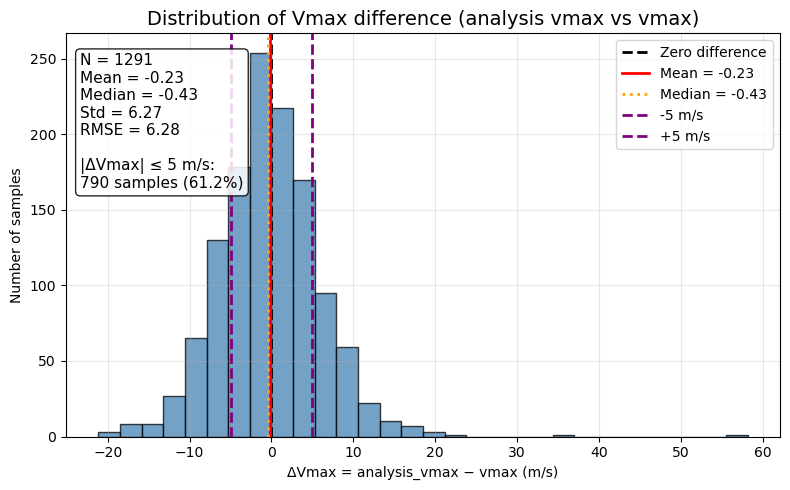

In [211]:
within_5 = np.sum((delta_vmax >= -5) & (delta_vmax <= 5))
pct_within_5 = 100 * within_5 / len(delta_vmax)


mean = np.mean(delta_vmax)
median = np.median(delta_vmax)
std = np.std(delta_vmax)
rmse = np.sqrt(np.mean(delta_vmax**2))

plt.figure(figsize=(8,5))

plt.hist(
    delta_vmax,
    bins=30,
    color="steelblue",
    alpha=0.75,
    edgecolor="black"
)

# lignes de référence
plt.axvline(0, color="black", linestyle="--", linewidth=2, label="Zero difference")
plt.axvline(mean, color="red", linestyle="-", linewidth=2,
            label=f"Mean = {mean:.2f}")
plt.axvline(median, color="orange", linestyle=":", linewidth=2,
            label=f"Median = {median:.2f}")
plt.axvline(-5, color="purple", linestyle="--", linewidth=2, label="-5 m/s")
plt.axvline(5, color="purple", linestyle="--", linewidth=2, label="+5 m/s")


plt.xlabel("ΔVmax = analysis_vmax − vmax (m/s)")
plt.ylabel("Number of samples")
plt.title("Distribution of Vmax difference (analysis vmax vs vmax)", fontsize=14)

plt.legend()
plt.grid(alpha=0.3)

# annotation stats
plt.text(
    0.02, 0.95,
    f"N = {len(delta_vmax)}\n"
    f"Mean = {mean:.2f}\n"
    f"Median = {median:.2f}\n"
    f"Std = {std:.2f}\n"
    f"RMSE = {rmse:.2f}\n\n"
    f"|ΔVmax| ≤ 5 m/s:\n"
    f"{within_5} samples ({pct_within_5:.1f}%)",
    transform=plt.gca().transAxes,
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)


plt.tight_layout()
plt.show()


## Split Data

In [8]:
import pandas as pd 
data = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/TCVA_matched_with_SARGEO_v2.csv")
train,val,test = data[data["split"]=="train"],data[data["split"]=="val"],data[data["split"]=="test"]

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ---------- Load + basic filtering ----------
data_primer = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/TCVA_matched_with_SARGEO_v2.csv")
data_primer["uid"] = np.arange(len(data_primer))
data_primer["split"] = "nan"   # default: not used

data = data_primer.copy()
data = data[~data["sar_aeqd_path"].isnull()].reset_index(drop=True)

data = data[data["nan_ratio_within_100km"] <= 0.5]
data = data[data["analysis_rmax"] <= 180000]

# Basin
data["bassin"] = data["cyclone_id"].astype(str).str[:2].str.lower()

# Convert rmax to km
data["analysis_rmax_km"] = data["analysis_rmax"] / 1000.0

# ---------- 1) test2_set: ANGGREK + MICHAEL ----------
mask_test2 = data["cyclone_name"].isin(["ANGGREK", "MICHAEL"])
test2_set = data[mask_test2].reset_index(drop=True)

data_main = data[~mask_test2].reset_index(drop=True)

# ---------- 2) force some samples into train ----------
cyclone_counts = data_main["cyclone_name"].value_counts()
mask_forced_train = (
    (data_main["analysis_center_quality_flag"] > 1.5) |
    (data_main["analysis_rmax"].isna()) |
    (data_main["analysis_vmax"].isna()) |
    (data_main["cyclone_name"].map(cyclone_counts) == 1)
)

train_forced = data_main[mask_forced_train].reset_index(drop=True)

# pool to split normally
pool = data_main[~mask_forced_train].reset_index(drop=True)

# ---------- 3) stratify pool by bassin + analysis_rmax (3 bins) ----------
# (Use qcut for balanced bins)
pool = pool.copy()
pool["rmax_bin"] = pd.qcut(
    pool["analysis_rmax_km"].rank(method="first"),
    q=2,
    labels=["petit","grand"]
)

pool["stratum"] = pool["cyclone_name"].astype(str)

# avoid stratify crash: merge rare strata
vc = pool["stratum"].value_counts()
rare = vc[vc < 3].index
pool.loc[pool["stratum"].isin(rare), "stratum"] = "RARE"

# ---------- 4) split pool -> train/val/test ----------
train_size, val_size, test_size = 0.6, 0.2, 0.2
temp_size = val_size + test_size

train_pool, temp = train_test_split(
    pool, test_size=temp_size, random_state=0, stratify=pool["stratum"]
)

# re-merge rare strata inside temp for second split
vc2 = temp["stratum"].value_counts()
rare2 = vc2[vc2 < 2].index
temp.loc[temp["stratum"].isin(rare2), "stratum"] = "RARE"

val_rel = val_size / (val_size + test_size)
val_set, test_set = train_test_split(
    temp, test_size=(1 - val_rel), random_state=0, stratify=temp["stratum"]
)

# ---------- 5) final train = train_pool + train_forced ----------
train_set = pd.concat([train_pool, train_forced], ignore_index=True)
train_set = train_set.sample(frac=1, random_state=0).reset_index(drop=True)

data_primer.loc[data_primer["uid"].isin(train_set["uid"]), "split"] = "train"
data_primer.loc[data_primer["uid"].isin(val_set["uid"]),   "split"] = "val"
data_primer.loc[data_primer["uid"].isin(test_set["uid"]),  "split"] = "test"
data_primer.loc[data_primer["uid"].isin(test2_set["uid"]), "split"] = "test2"

# sanity
print(data_primer["split"].value_counts())

# ---------- Print summary ----------
print("train:", len(train_set), "val:", len(val_set), "test:", len(test_set), "test2:", len(test2_set))
print("basins train:", train_set["bassin"].value_counts().to_dict())
print("basins val:",   val_set["bassin"].value_counts().to_dict())
print("basins test:",  test_set["bassin"].value_counts().to_dict())
print("cyclone_train train:", train_set["cyclone_name"].value_counts().to_dict())
print("cyclone val:",   val_set["cyclone_name"].value_counts().to_dict())
print("cyclone test:",  test_set["cyclone_name"].value_counts().to_dict())


split
train    821
nan      530
val      171
test     171
test2     21
Name: count, dtype: int64
train: 821 val: 171 test: 171 test2: 21
basins train: {'sh': 228, 'al': 214, 'wp': 187, 'ep': 156, 'io': 24, 'cp': 12}
basins val: {'sh': 53, 'wp': 40, 'al': 39, 'ep': 36, 'io': 2, 'cp': 1}
basins test: {'sh': 53, 'wp': 38, 'ep': 37, 'al': 37, 'io': 3, 'cp': 3}
cyclone_train train: {'TALIAH': 17, 'FREDDY': 14, 'ERIN': 13, 'ALFRED': 12, 'HONDE': 9, 'KHANUN': 9, 'VINCE': 9, 'HONE': 9, 'LEE': 9, 'KIRK': 8, 'ERNESTO': 8, 'YINXING': 8, 'HUMBERTO': 8, 'GILMA': 8, 'DIKELEDI': 8, 'LESLIE': 8, 'KIKO': 7, 'FRANKLIN': 7, 'MELISSA': 7, 'KOINU': 7, 'HENRIETTE': 7, 'BERYL': 7, 'MUN': 6, 'JASPER': 6, 'BHEKI': 6, 'DARIAN': 6, 'CALVIN': 6, 'LAN': 6, 'SURIGAE': 6, 'SAOLA': 6, 'MINDULLE': 6, 'PODUL': 6, 'MARGOT': 6, 'DORA': 6, 'COURTNEY': 5, 'DOKSURI': 5, 'MAWAR': 5, 'YAGI': 5, 'NORMA': 5, 'RAFAEL': 5, 'OCTAVE': 5, 'HELENE': 5, 'JULIETTE': 5, 'CHIDO': 5, 'TAMMY': 5, 'NARDA': 5, 'GABRIELLE': 5, 'MAN-YI': 5, 'K

In [206]:
count = 0
for key in list(val_set["cyclone_name"].value_counts().to_dict().keys()):
    if key in list(train_set["cyclone_name"].value_counts().to_dict().keys()):
        count+=1
len(val_set["cyclone_name"].value_counts().to_dict().keys()),count

(127, 125)

In [200]:
data_primer.columns

Index(['Unnamed: 0', 'cyclone_name', 'cyclone_id', 'sar_time', 'file',
       'match_type', 'analysis_center_quality_flag', 'analysis_vmax',
       'analysis_rmax', 'vmax', 'sar_aeqd_path', 'sargeo_path',
       'nan_ratio_within_100km', 'split', 'uid'],
      dtype='object')

Train original: 821
Train augmented: 1837


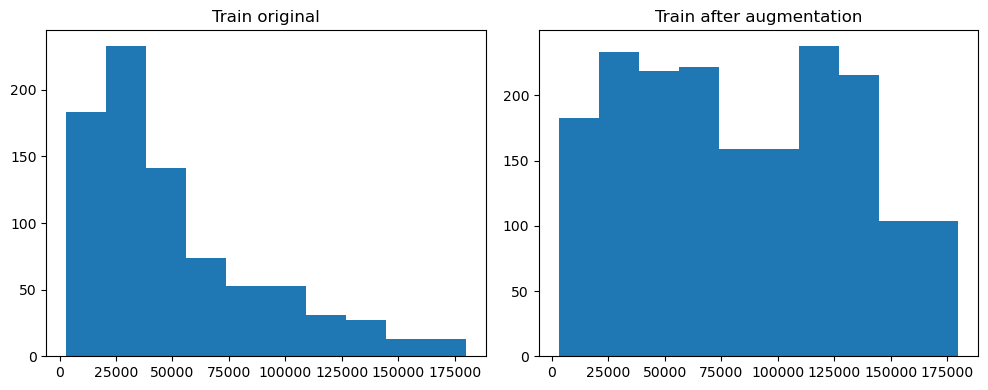

In [202]:
# Base train
train_base = data_primer[data_primer["split"]=="train"].copy()

# 1) Dupliquer toute la base ×3
train_aug = train_base

# 2) rmax entre 40k et 90k → ×2
mask_mid = (train_base["analysis_rmax"] >= 50_000) & (train_base["analysis_rmax"] <= 110_000)  #hflip and vlip 
train_mid = train_base[mask_mid]
train_aug = pd.concat([train_aug, train_mid, train_mid], ignore_index=True)

# 3) rmax > 90k → ×5
mask_large = train_base["analysis_rmax"] > 110_000
train_large = train_base[mask_large]
train_aug = pd.concat(
    [train_aug] + [train_large] * 7, #[flip h and v (roatte 90 , 180, 270) and add noise (0.05)]
    ignore_index=True
)

# 4) Shuffle (IMPORTANT)
train_aug = train_aug.sample(frac=1, random_state=42).reset_index(drop=True)

print("Train original:", len(data_primer[data_primer["split"]=="train"]))
print("Train augmented:", len(train_aug))
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(data_primer[data_primer["split"]=="train"]["analysis_rmax"])
plt.title("Train original")

plt.subplot(1,2,2)
plt.hist(train_aug["analysis_rmax"])
plt.title("Train after augmentation")

plt.tight_layout()
plt.show()


In [201]:
data_primer[["cyclone_name","cyclone_id","sar_time","file","match_type","analysis_center_quality_flag","analysis_rmax","analysis_vmax","vmax","sar_aeqd_path","sargeo_path","nan_ratio_within_100km","split"]].to_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/TCVA_matched_with_SARGEO_v3_split_by_cyclone_name.csv")

## GPM SAR colocs

In [63]:
import pandas as pd
count=0
data = pd.read_csv("/scale/user/mtannaou/alternance/excels/colocates_sargeo_primed_90min_v1.csv")

tcprimed_paths,sargeo_paths,dates_tcprimed,sargeo_times = [],[],[],[]
paths_tcprimed_completed = []
cyclons_id = []
chemin_tcprimed = "/scale/project/ifremer-isi-jumeaunumerique/TC_PRIMED_DATASET/v01r01/final"
for i,row in data[data["count"]!=0].iterrows():
    
    for path_tc,date_tc,diff_time in zip(row["path_tcprimed"].split("[")[1].split("]")[0].split(","),row["date_tcprimed"].split("[")[1].split("]")[0].split(","),row["diff_time"].split("[")[1].split("]")[0].split(",")):
        path_tc = path_tc.replace(" ","")
        date_tc = date_tc.replace(" ","")
        diff_time = diff_time.replace(" ","")


        if "GPM" in path_tc and float(diff_time) <= 60*60:
            tcprimed_paths.append(path_tc)
            sargeo_paths.append(row["path_sargeo"])
            dates_tcprimed.append(date_tc)
            sargeo_times.append(row["date_sargeo"])
            cyclons_id.append(row["cyclone_id"])
            paths_tcprimed_completed.append((os.path.join(chemin_tcprimed,row["cyclone_id"][-4:],row["cyclone_id"][:2].upper(),row["cyclone_id"][2:4],path_tc)).replace("'T","T").replace("'",""))
            
            count +=1
            continue
count



59

In [64]:
import os
sar_paths = []
sargeo_paths_complete = []
count=0
cyclobs_path = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v00r00/cyclobs"

data_sargeo = pd.read_csv("/scale/user/mtannaou/alternance/excels/SARGEO_SAR_v00r00_16_janvier_v1.csv")
for sargeo_path in sargeo_paths:
    match = data_sargeo[data_sargeo["fichier"]==sargeo_path]
    if len(match) ==1:
        sargeo_paths_complete.append(os.path.join(cyclobs_path,match["cyclone"].values[0],"IRWIN",match["fichier"].values[0]))
        sar_paths.append(match["sar_path"].values[0])
        count+=1

        
count


59

In [5]:
import pandas as pd
tcva_sargeo = pd.read_csv("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/csv_data/TCVA_matched_with_SARGEO_v3_split_by_year.csv")
cyclobs = pd.read_csv("https://cyclobs.ifremer.fr/app/api/getData?include_cols=data_url,eye_center")
len(cyclobs),len(tcva_sargeo)

(2719, 1714)

POINT (-82.32040119492252 18.62265760607904)

In [49]:
import numpy as np
def wkt_to_lat_lon(wkt):
    '''
    (longitude, lattude)
    '''

    try : 
        if np.isnan(wkt):
            return None,None
    except:

        lon,lat = wkt.split("(")[-1].split(")")[0].split(" ")
        lon = (float(lon) +180)%360 - 180
        return lon,float(lat) if lat is not None else lat
wkt_to_lat_lon("POINT (-82.32040119492252 18.62265760607904)")

(-82.32040119492252, 18.62265760607904)

In [51]:
count = 0
for i,row in tcva_sargeo[~tcva_sargeo["sar_aeqd_path"].isna()].iterrows():
    sar_aeqd_path = row["sar_aeqd_path"].split("/")[-1].split("_aeqd")[0]
    match = cyclobs[cyclobs["data_url"].str.contains(sar_aeqd_path)]
    
    if len(match)==1:
        wkt = match["eye_center"].values
        lon_eye, lat_eye = wkt_to_lat_lon(wkt[0])
        tcva_sargeo.loc[i,"lon_eye"] = lon_eye
        tcva_sargeo.loc[i,"lat_eye"] = lat_eye
count,len(tcva_sargeo[~tcva_sargeo["sar_aeqd_path"].isna()])

(0, 1705)

In [55]:
tcva_sargeo.columns

Index(['Unnamed: 0', 'cyclone_name', 'cyclone_id', 'sar_time', 'file',
       'match_type', 'analysis_center_quality_flag', 'analysis_rmax',
       'analysis_vmax', 'vmax', 'sar_aeqd_path', 'sargeo_path',
       'nan_ratio_within_100km', 'split', 'tcprimed_env_exist',
       'tcprimed_env_path', 'index_in_env_ds', 'storm_latitude',
       'storm_longitude', 'coriolis', 'lon_eye', 'lat_eye'],
      dtype='object')

In [58]:
import numpy as np

def distance_km(lat1, lon1, lat2, lon2):
    """
    Calcule la distance en km entre deux points GPS.
    Entrées en degrés.
    Compatible scalaires ou numpy arrays.
    """
    
    # rayon de la Terre (km)
    R = 6371.0
    
    # conversion en radians
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    # différences
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # formule haversine
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    return R * c


In [60]:
tcva_sargeo["distance_km"] = distance_km(
    tcva_sargeo["storm_latitude"],
    tcva_sargeo["storm_longitude"],
    tcva_sargeo["lat_eye"],
    tcva_sargeo["lon_eye"]
)


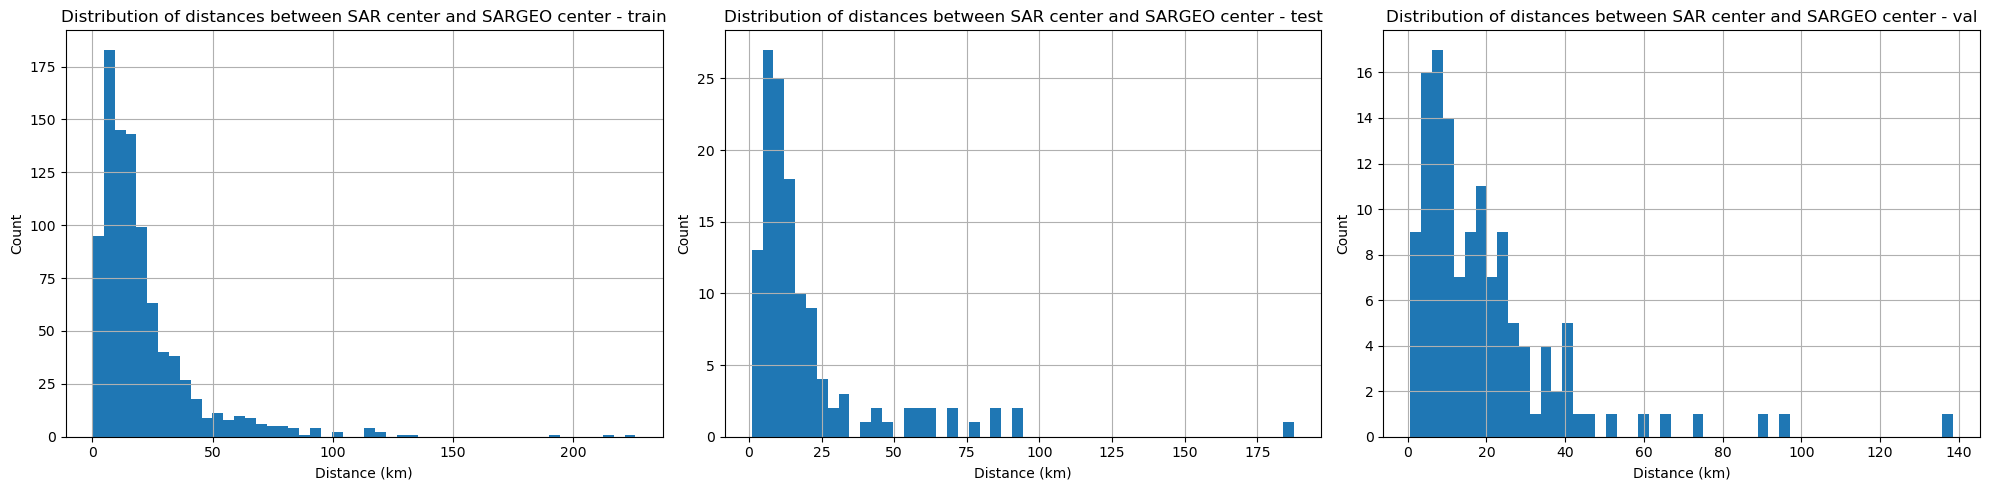

In [138]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
splits = ["train", "test", "val"]
for ax, s in zip(axes, splits):
    tcva_sargeo[tcva_sargeo["split"] == s]["distance_km"].hist(
        bins=50, ax=ax
    )
    ax.set_title(f"Distribution of distances between SAR center and SARGEO center - {s}")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [143]:
import pickle as pkl
with open("/scale/user/mtannaou/alternance/src/IR_to_SAR/ML_IR_SAR/combined_loss/train_ir_sar_1/stats_normalisation/OUTPUT/stats.pkl","rb") as f:
    stats_sar_train  = pkl.load(f)
mean_sar = stats_sar_train["mean_sar"]
std_sar = stats_sar_train["std_sar"]

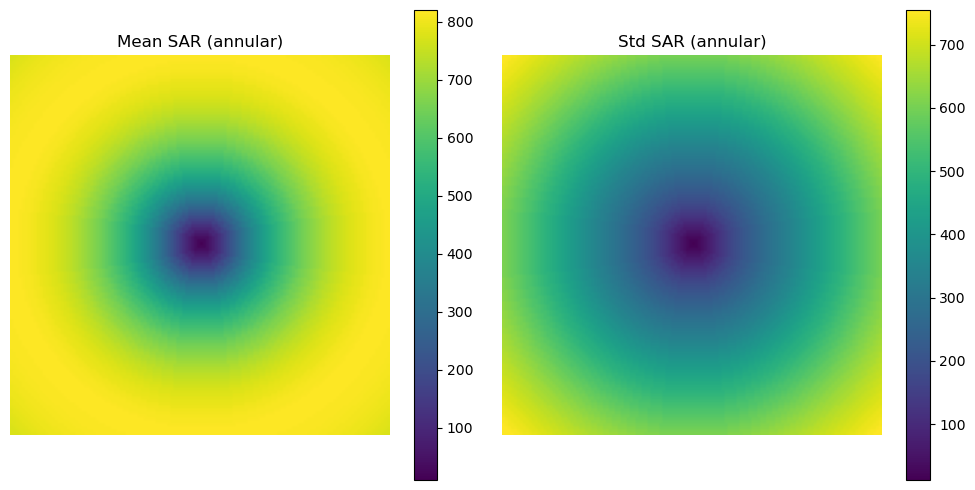

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def annular_stats_to_image(values, H=128, W=128, bin_size=1):
    """
    Convertit des stats par anneau en image 2D circulaire.
    """
    cy, cx = H // 2, W // 2
    y, x = np.indices((H, W))
    radius = np.sqrt((y - cy)**2 + (x - cx)**2)
    radial_bins = (radius // bin_size).astype(np.int32)

    img = np.zeros((H, W))
    max_bin = min(len(values), radial_bins.max() + 1)

    for b in range(max_bin):
        img[radial_bins == b] = values[b]

    return img


mean_vals = stats_sar_train["mean_sar"]
std_vals  = stats_sar_train["std_sar"]

mean_img = annular_stats_to_image(mean_vals)
std_img  = annular_stats_to_image(std_vals)

vmin_mean, vmax_mean = np.min(mean_vals), np.max(mean_vals)
vmin_std,  vmax_std  = np.min(std_vals),  np.max(std_vals)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

im0 = axes[0].imshow(mean_img, origin="lower",
                     vmin=vmin_mean, vmax=vmax_mean)
axes[0].set_title("Mean SAR (annular)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(std_img, origin="lower",
                     vmin=vmin_std, vmax=vmax_std)
axes[1].set_title("Std SAR (annular)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()